# 10 — Random Forest with MLflow

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook trains a controlled Random Forest on the complete model-ready training split. It evaluates the model on the same chronological validation period as the baseline and Linear Regression. Test targets remain untouched until model selection is complete.

## 1. Why this model is controlled

Random Forest can learn non-linear rules but may use too much memory on millions of rows. The number and depth of trees, leaf size, features per split, and bootstrap sample are deliberately limited. All training rows are passed to `fit`; each tree then uses a reproducible bootstrap sample, which is the normal Random Forest procedure.

In [1]:
from pathlib import Path
import platform
import time

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from mlflow.models import infer_signature
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        feature_dir = candidate / "data" / "processed" / "m5_foods_features"
        if (feature_dir / "train.parquet").exists() and (feature_dir / "validation.parquet").exists():
            return candidate.resolve()
    raise FileNotFoundError("Feature files were not found. Run notebook 07 first.")

PROJECT_ROOT = find_project_root()
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_features"
REPORT_DIR = PROJECT_ROOT / "reports"
MLRUNS_DIR = PROJECT_ROOT / "mlruns"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"
REPORT_DIR.mkdir(exist_ok=True)
MLRUNS_DIR.mkdir(exist_ok=True)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)

Python: 3.10.11
scikit-learn: 1.7.2
MLflow: 3.15.0


## 2. Load train and validation only

The same 20 numeric leakage-safe features are used for a fair comparison. Store and department identifiers are kept only for grouped evaluation.

In [2]:
numeric_features = [
    "sales_lag_1", "sales_lag_2", "sales_lag_4", "sales_lag_8",
    "sales_roll_mean_4", "sales_roll_std_4",
    "sales_roll_mean_8", "sales_roll_std_8",
    "zero_weeks_last_4",
    "sell_price_mean", "price_lag_1", "price_change_pct",
    "year", "month", "week_of_year", "quarter",
    "event_days", "has_event", "snap_days", "has_snap",
]
target = "weekly_units_sold"
metadata_columns = ["week_start", "dept_id", "store_id", "dataset_split"]
load_columns = metadata_columns + numeric_features + [target]

train = pd.read_parquet(FEATURE_DIR / "train.parquet", columns=load_columns)
validation = pd.read_parquet(FEATURE_DIR / "validation.parquet", columns=load_columns)
X_train = train[numeric_features].astype("float32")
y_train = train[target].astype("float32")
X_validation = validation[numeric_features].astype("float32")
y_validation = validation[target].astype("float32")

print("Train rows:", f"{len(train):,}")
print("Validation rows:", f"{len(validation):,}")
print("Numeric features:", len(numeric_features))

Train rows: 2,888,944
Validation rows: 57,478
Numeric features: 20


## 3. Train the controlled forest

Fixed `random_state=42` makes the bootstrap samples and trained model reproducible. The parameters below prioritize a course-appropriate runtime over an exhaustive search.

In [3]:
model_parameters = {
    "n_estimators": 40,
    "max_depth": 14,
    "min_samples_leaf": 20,
    "max_features": 0.7,
    "max_samples": 0.5,
    "bootstrap": True,
    "n_jobs": -1,
    "random_state": 42,
}
model = RandomForestRegressor(**model_parameters)

fit_started = time.perf_counter()
model.fit(X_train, y_train)
fit_seconds = time.perf_counter() - fit_started

predict_started = time.perf_counter()
predictions = model.predict(X_validation)
predict_seconds = time.perf_counter() - predict_started

print("Fit seconds:", f"{fit_seconds:,.2f}")
print("Validation prediction seconds:", f"{predict_seconds:,.2f}")
print("Fitted trees:", len(model.estimators_))

Fit seconds: 159.89
Validation prediction seconds: 0.09
Fitted trees: 40


## 4. Compare all validation methods

MAE remains the primary selection metric. All methods use the same chronological validation period.

In [4]:
def regression_metrics(actual, predicted):
    error = predicted - actual
    return {
        "mae": float(np.abs(error).mean()),
        "rmse": float(np.sqrt(np.square(error).mean())),
        "mean_error": float(error.mean()),
    }

forest_metrics = regression_metrics(y_validation.to_numpy(), predictions)
baseline_report = pd.read_csv(REPORT_DIR / "baseline_metrics_validation.csv")
baseline_reference = baseline_report.loc[baseline_report["baseline"].eq("previous_4_week_mean")].iloc[0]
linear_report = pd.read_csv(REPORT_DIR / "linear_regression_metrics_validation.csv")
linear_reference = linear_report.loc[linear_report["method"].eq("linear_regression_clipped")].iloc[0]
mae_improvement_vs_baseline_pct = 100 * (baseline_reference["mae"] - forest_metrics["mae"]) / baseline_reference["mae"]
rmse_improvement_vs_baseline_pct = 100 * (baseline_reference["rmse"] - forest_metrics["rmse"]) / baseline_reference["rmse"]

comparison = pd.DataFrame([
    {"method": "previous_4_week_mean", "rows": len(validation), "mae": baseline_reference["mae"], "rmse": baseline_reference["rmse"], "mean_error": baseline_reference["mean_error"]},
    {"method": "linear_regression_clipped", "rows": len(validation), "mae": linear_reference["mae"], "rmse": linear_reference["rmse"], "mean_error": linear_reference["mean_error"]},
    {"method": "random_forest", "rows": len(validation), **forest_metrics},
]).sort_values("mae").reset_index(drop=True)
best_validation_method = comparison.iloc[0]["method"]
display(comparison)
print("MAE improvement versus baseline (%):", f"{mae_improvement_vs_baseline_pct:,.3f}")
print("Best validation method:", best_validation_method)

,method,rows,mae,rmse,mean_error
0,random_forest,57478,4.2698,9.1372,0.1141
1,previous_4_week_mean,57478,4.5172,10.1300,-0.0255
2,linear_regression_clipped,57478,4.7662,10.5693,-0.2911


MAE improvement versus baseline (%): 5.476
Best validation method: random_forest


## 5. Grouped evaluation and feature importance

Grouped metrics reveal weak stores or departments. Random Forest feature importance shows which inputs were used most often to reduce prediction error, but it does not prove causality.

In [5]:
validation_results = validation[["week_start", "store_id", "dept_id", target]].copy()
validation_results["prediction"] = predictions

def grouped_metrics(data, group_column):
    rows = []
    for group_value, group in data.groupby(group_column, observed=True):
        rows.append({
            group_column: group_value,
            "rows": len(group),
            **regression_metrics(group[target].to_numpy(), group["prediction"].to_numpy()),
        })
    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)

store_metrics = grouped_metrics(validation_results, "store_id")
department_metrics = grouped_metrics(validation_results, "dept_id")
feature_importance = pd.DataFrame({
    "feature": numeric_features,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(store_metrics)
display(department_metrics)
display(feature_importance.head(10))

,store_id,rows,mae,rmse,mean_error
0,CA_4,5748,3.1050,5.1995,0.0453
1,TX_1,5748,3.4348,6.8396,0.1924
2,TX_3,5748,3.7317,7.5533,0.4707
3,TX_2,5748,3.7363,7.0963,0.8751
4,WI_1,5748,3.8901,6.8574,0.2378
5,CA_2,5748,4.3379,7.7407,-0.4708
6,CA_1,5747,4.4947,9.0234,-0.1553
7,WI_3,5748,4.5298,9.6652,0.0975
8,CA_3,5747,5.3327,10.7801,0.2906
9,WI_2,5748,6.1053,15.9896,-0.4425


,dept_id,rows,mae,rmse,mean_error
0,FOODS_2,15920,3.3472,6.9473,-0.1157
1,FOODS_1,8640,3.7834,6.7833,0.8268
2,FOODS_3,32918,4.8437,10.5051,0.0381


,feature,importance
0,sales_lag_1,0.5041
1,sales_roll_mean_4,0.3515
2,sales_roll_mean_8,0.0665
3,sales_lag_2,0.0493
4,sales_roll_std_4,0.0050
5,sales_roll_std_8,0.0043
6,sales_lag_4,0.0042
7,snap_days,0.0031
8,sales_lag_8,0.0029
9,price_lag_1,0.0022


## 6. Verification before MLflow

The model is not required to win, but the data scope, predictions, row accounting, feature importances, and split order must all be valid.

In [6]:
feature_summary = pd.read_csv(REPORT_DIR / "feature_split_summary.csv").set_index("split")
checks = pd.DataFrame([
    {"check": "expected train rows", "status": "PASS" if len(train) == int(feature_summary.loc["train", "rows_after"]) else "FAIL", "details": str(len(train))},
    {"check": "expected validation rows", "status": "PASS" if len(validation) == int(feature_summary.loc["validation", "rows_after"]) else "FAIL", "details": str(len(validation))},
    {"check": "train split only", "status": "PASS" if train["dataset_split"].eq("train").all() else "FAIL", "details": str(train["dataset_split"].unique().tolist())},
    {"check": "validation split only", "status": "PASS" if validation["dataset_split"].eq("validation").all() else "FAIL", "details": str(validation["dataset_split"].unique().tolist())},
    {"check": "chronological split order", "status": "PASS" if train["week_start"].max() < validation["week_start"].min() else "FAIL", "details": "train max < validation min"},
    {"check": "target excluded from features", "status": "PASS" if target not in numeric_features else "FAIL", "details": target},
    {"check": "model inputs contain no nulls", "status": "PASS" if not X_train.isna().any().any() and not X_validation.isna().any().any() else "FAIL", "details": "train and validation"},
    {"check": "finite predictions", "status": "PASS" if np.isfinite(predictions).all() else "FAIL", "details": str(len(predictions))},
    {"check": "non-negative predictions", "status": "PASS" if (predictions >= 0).all() else "FAIL", "details": "non-negative training target"},
    {"check": "fitted tree count", "status": "PASS" if len(model.estimators_) == model_parameters["n_estimators"] else "FAIL", "details": str(len(model.estimators_))},
    {"check": "feature importance total", "status": "PASS" if np.isclose(feature_importance["importance"].sum(), 1.0) else "FAIL", "details": f"{feature_importance['importance'].sum():.6f}"},
    {"check": "store row accounting", "status": "PASS" if int(store_metrics["rows"].sum()) == len(validation) else "FAIL", "details": str(int(store_metrics["rows"].sum()))},
    {"check": "department row accounting", "status": "PASS" if int(department_metrics["rows"].sum()) == len(validation) else "FAIL", "details": str(int(department_metrics["rows"].sum()))},
    {"check": "test file not loaded", "status": "PASS", "details": "train.parquet + validation.parquet"},
])
assert checks["status"].eq("PASS").all()
display(checks)

,check,status,details
0,expected train rows,PASS,2888944
1,expected validation rows,PASS,57478
2,train split only,PASS,['train']
3,validation split only,PASS,['validation']
4,chronological split order,PASS,train max < validation min
5,target excluded from features,PASS,weekly_units_sold
6,model inputs contain no nulls,PASS,train and validation
7,finite predictions,PASS,57478
8,non-negative predictions,PASS,non-negative training target
9,fitted tree count,PASS,40


## 7. Save reports and record MLflow run

The local SQLite MLflow store already contains the Linear Regression run. This notebook adds one Random Forest run with parameters, metrics, reports, and the fitted model.

In [7]:
comparison.to_csv(REPORT_DIR / "random_forest_metrics_validation.csv", index=False)
store_metrics.to_csv(REPORT_DIR / "random_forest_store_metrics_validation.csv", index=False)
department_metrics.to_csv(REPORT_DIR / "random_forest_department_metrics_validation.csv", index=False)
feature_importance.to_csv(REPORT_DIR / "random_forest_feature_importance.csv", index=False)
checks.to_csv(REPORT_DIR / "random_forest_checks.csv", index=False)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment("retail-demand-forecasting")
signature = infer_signature(X_validation.head(1000), model.predict(X_validation.head(1000)))
input_example = X_validation.head(5)

with mlflow.start_run(run_name="random-forest-controlled-v1") as run:
    mlflow.log_params({
        "model_type": "RandomForestRegressor",
        **model_parameters,
        "numeric_feature_count": len(numeric_features),
        "train_rows": len(train),
        "validation_rows": len(validation),
        "target": target,
        "split_strategy": "chronological",
    })
    mlflow.log_metrics({
        "validation_mae": forest_metrics["mae"],
        "validation_rmse": forest_metrics["rmse"],
        "validation_mean_error": forest_metrics["mean_error"],
        "baseline_mae": float(baseline_reference["mae"]),
        "baseline_rmse": float(baseline_reference["rmse"]),
        "linear_regression_mae": float(linear_reference["mae"]),
        "mae_improvement_vs_baseline_pct": float(mae_improvement_vs_baseline_pct),
        "rmse_improvement_vs_baseline_pct": float(rmse_improvement_vs_baseline_pct),
        "fit_seconds": float(fit_seconds),
        "predict_seconds": float(predict_seconds),
    })
    for report_name in [
        "random_forest_metrics_validation.csv",
        "random_forest_store_metrics_validation.csv",
        "random_forest_department_metrics_validation.csv",
        "random_forest_feature_importance.csv",
        "random_forest_checks.csv",
    ]:
        mlflow.log_artifact(REPORT_DIR / report_name, artifact_path="reports")
    mlflow.log_text("\n".join(numeric_features), "numeric_features.txt")
    mlflow.sklearn.log_model(model, name="model", signature=signature, input_example=input_example)
    run_id = run.info.run_id

recorded_run = mlflow.get_run(run_id)
reloaded_model = mlflow.sklearn.load_model(f"runs:/{run_id}/model")
reloaded_predictions = reloaded_model.predict(X_validation)
reloaded_mae = regression_metrics(y_validation.to_numpy(), reloaded_predictions)["mae"]
reload_matches = bool(np.isclose(reloaded_mae, forest_metrics["mae"]))
checks = pd.concat([checks, pd.DataFrame([
    {"check": "MLflow run finished", "status": "PASS" if recorded_run.info.status == "FINISHED" else "FAIL", "details": recorded_run.info.status},
    {"check": "MLflow model reload reproduces MAE", "status": "PASS" if reload_matches else "FAIL", "details": f"{reloaded_mae:.6f}"},
])], ignore_index=True)
assert checks["status"].eq("PASS").all()
checks.to_csv(REPORT_DIR / "random_forest_checks.csv", index=False)
mlflow.tracking.MlflowClient().log_artifact(run_id, REPORT_DIR / "random_forest_checks.csv", artifact_path="reports")

mlflow_summary = pd.DataFrame([{
    "experiment_name": "retail-demand-forecasting",
    "run_name": "random-forest-controlled-v1",
    "run_id": run_id,
    "tracking_uri": "sqlite:///mlflow.db",
    "sklearn_version": sklearn.__version__,
    "mlflow_version": mlflow.__version__,
    "train_rows": len(train),
    "validation_rows": len(validation),
    "feature_count": len(numeric_features),
    "fit_seconds": fit_seconds,
    "predict_seconds": predict_seconds,
    "run_status": recorded_run.info.status,
    "model_reload_check": "PASS" if reload_matches else "FAIL",
    "reloaded_model_mae": reloaded_mae,
    "validation_mae": forest_metrics["mae"],
    "validation_rmse": forest_metrics["rmse"],
    "baseline_mae": float(baseline_reference["mae"]),
    "mae_improvement_vs_baseline_pct": mae_improvement_vs_baseline_pct,
    "best_validation_method": best_validation_method,
}])
mlflow_summary.to_csv(REPORT_DIR / "mlflow_random_forest_run.csv", index=False)
display(mlflow_summary)

,experiment_name,run_name,run_id,tracking_uri,sklearn_version,mlflow_version,train_rows,validation_rows,feature_count,fit_seconds,predict_seconds,run_status,model_reload_check,reloaded_model_mae,validation_mae,validation_rmse,baseline_mae,mae_improvement_vs_baseline_pct,best_validation_method
0,retail-demand-forecasting,random-forest-controlled-v1,6296b080db24427bb327b1a73db4c81c,sqlite:///mlflow.db,1.7.2,3.15.0,2888944,57478,20,159.8904,0.0867,FINISHED,PASS,4.2698,4.2698,9.1372,4.5172,5.4761,random_forest


## 8. Visual review

The charts compare validation MAE and show the ten most important Random Forest inputs.

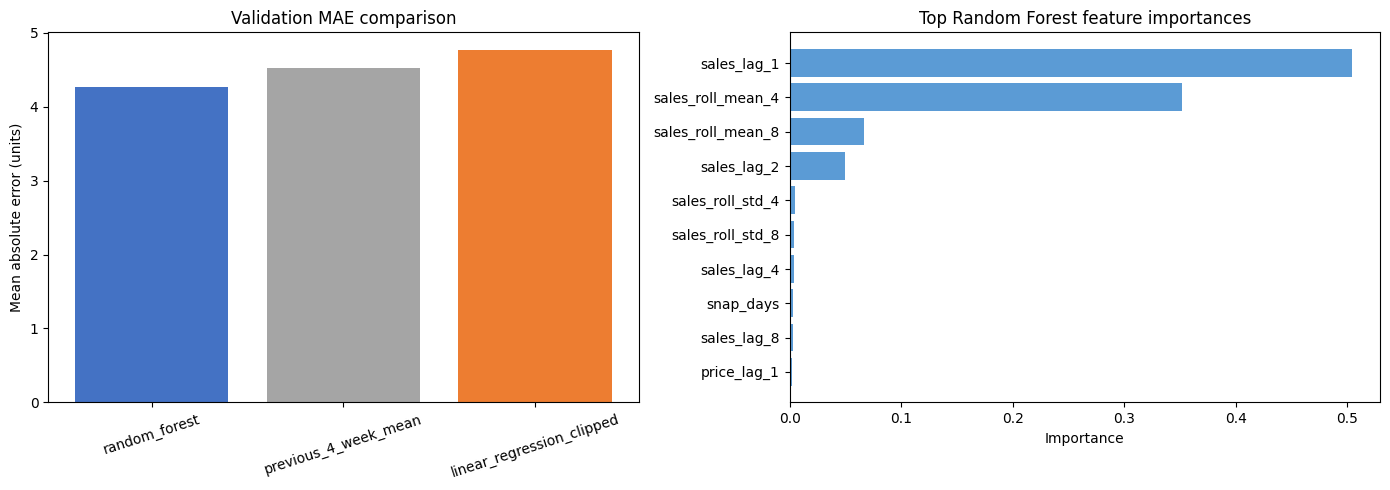

In [8]:
top_importance = feature_importance.head(10).sort_values("importance")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(comparison["method"], comparison["mae"], color=["#4472C4", "#A5A5A5", "#ED7D31"])
axes[0].set_title("Validation MAE comparison")
axes[0].set_ylabel("Mean absolute error (units)")
axes[0].tick_params(axis="x", rotation=18)
axes[1].barh(top_importance["feature"], top_importance["importance"], color="#5B9BD5")
axes[1].set_title("Top Random Forest feature importances")
axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Result

The method with the lowest validation MAE is selected for the one-time test evaluation. No test result is produced in this notebook.